# 02 · What the fires look like

Descriptive groundwork before modelling. Two facts shape both later questions:
**burning is spatially concentrated** (Punjab ≫ Haryana; a handful of districts dominate)
and **weakly related to weather** at the seasonal scale.

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(ROOT)
if os.path.join(ROOT, 'src') not in sys.path: sys.path.insert(0, os.path.join(ROOT, 'src'))
import pandas as pd, numpy as np
from IPython.display import Image, display
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 40)
print('project root:', ROOT)

project root: E:\New folder (3)


In [2]:
import fire_policy.eda as E
fire, weather = E._load()
means = (fire.groupby('state')['dm_tonnes'].sum()/1e6/fire.year.nunique()).round(2)
print('Mean annual DM burned (Mt):', means.to_dict())
print('Punjab share of two-state total: %.0f%%' % (100*fire[fire.state=='Punjab'].dm_tonnes.sum()/fire.dm_tonnes.sum()))

Mean annual DM burned (Mt): {'Haryana': 1.47, 'Punjab': 8.8}
Punjab share of two-state total: 86%


### State trend & the worst districts
Punjab burns ~6× Haryana; Sangrur, Bathinda, Moga, Ludhiana and Muktsar lead.

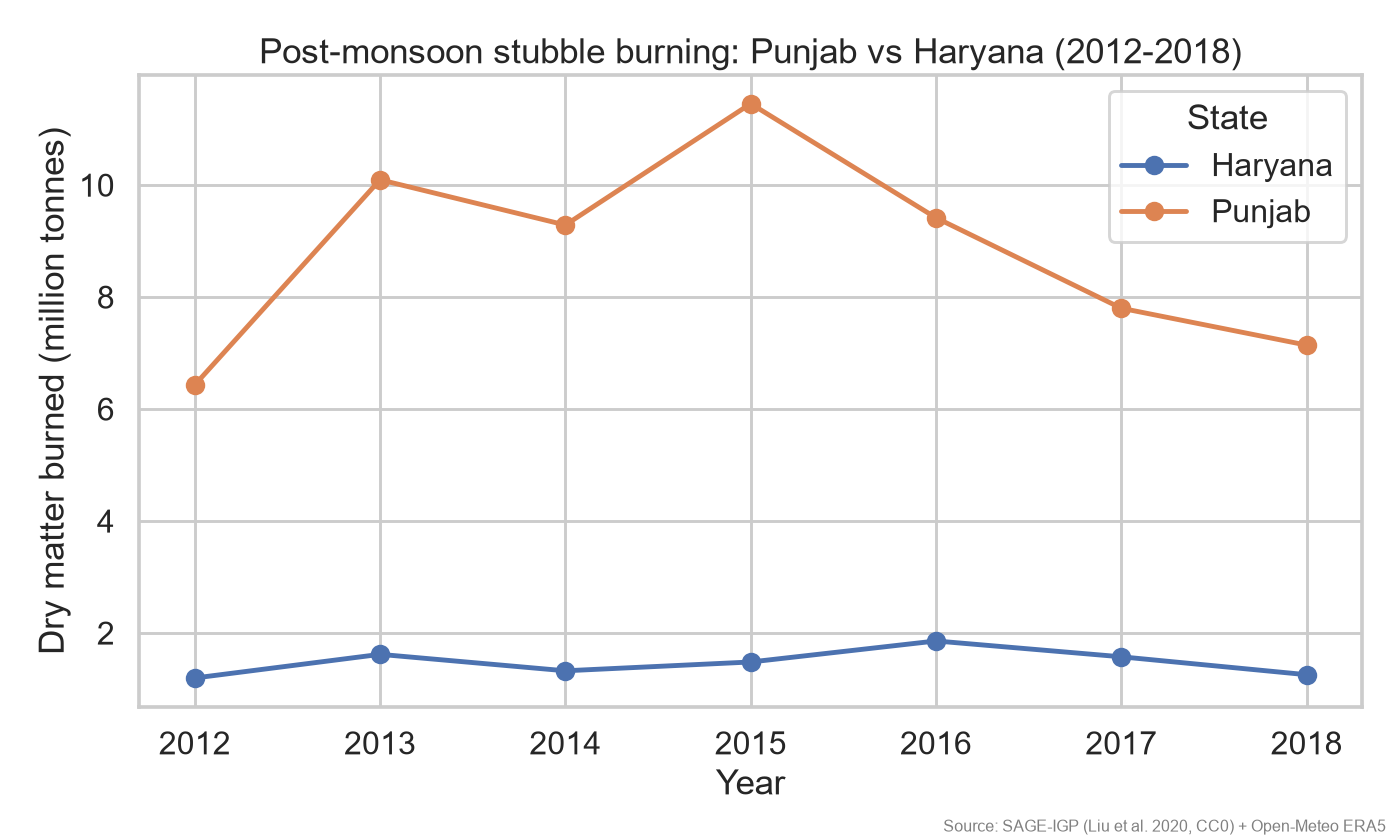

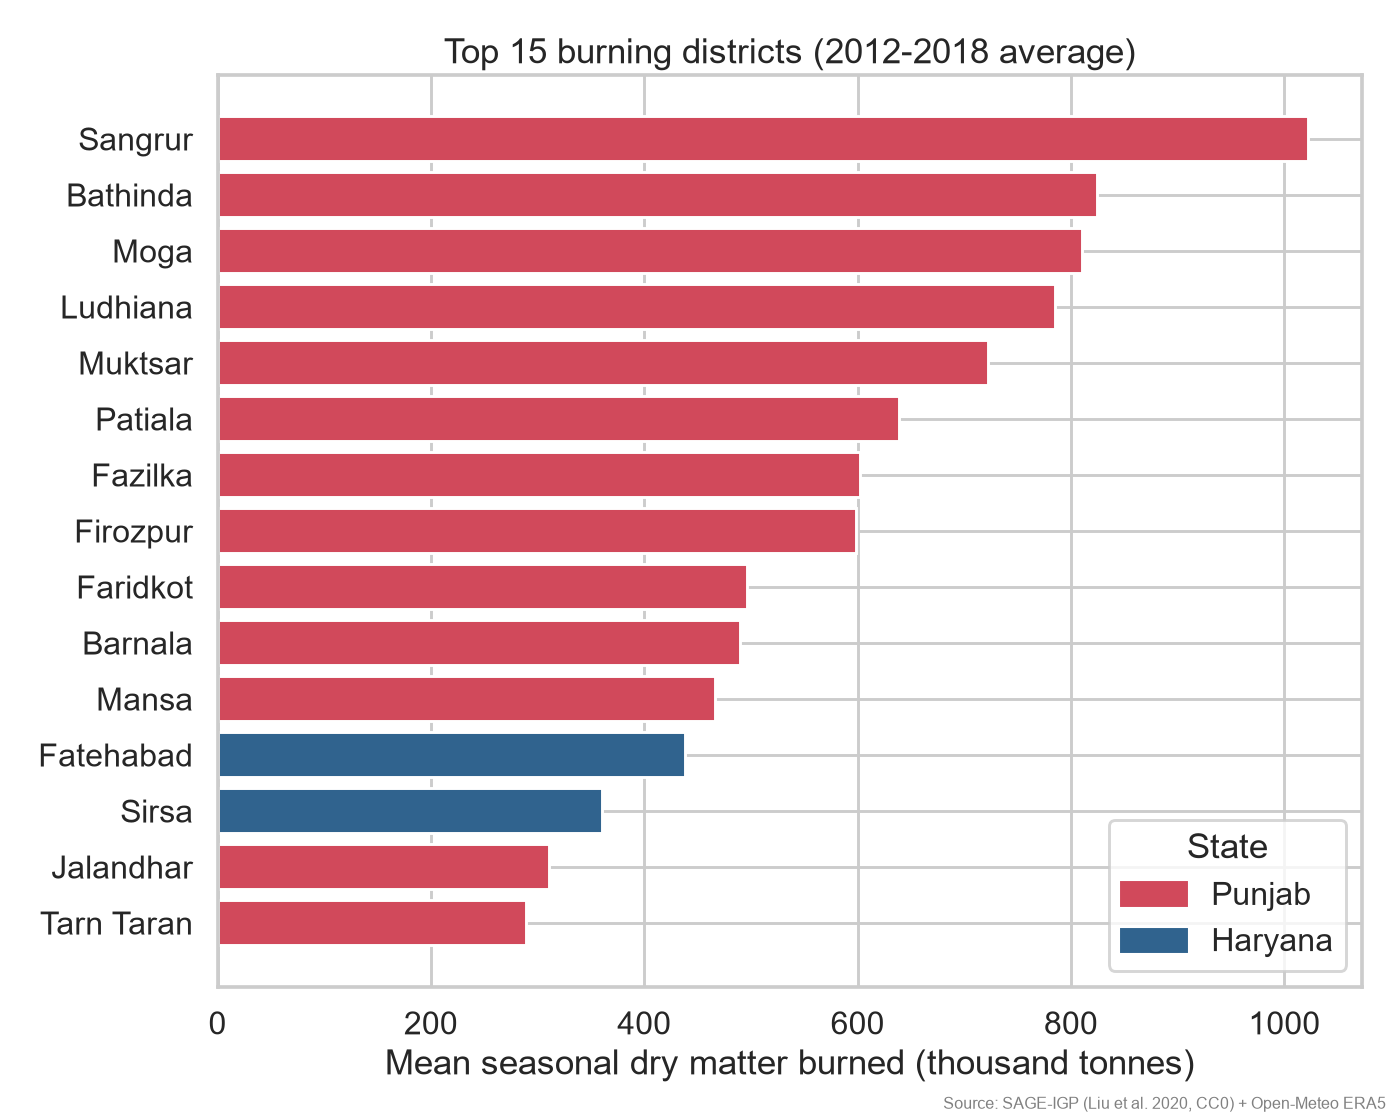

In [3]:
for _p in ['reports/figures/01_state_trend.png', 'reports/figures/02_top_districts.png']:
    display(Image(filename=_p))

### When does it peak?
A tight early-November spike — the ~2–3 week paddy-to-wheat turnaround.

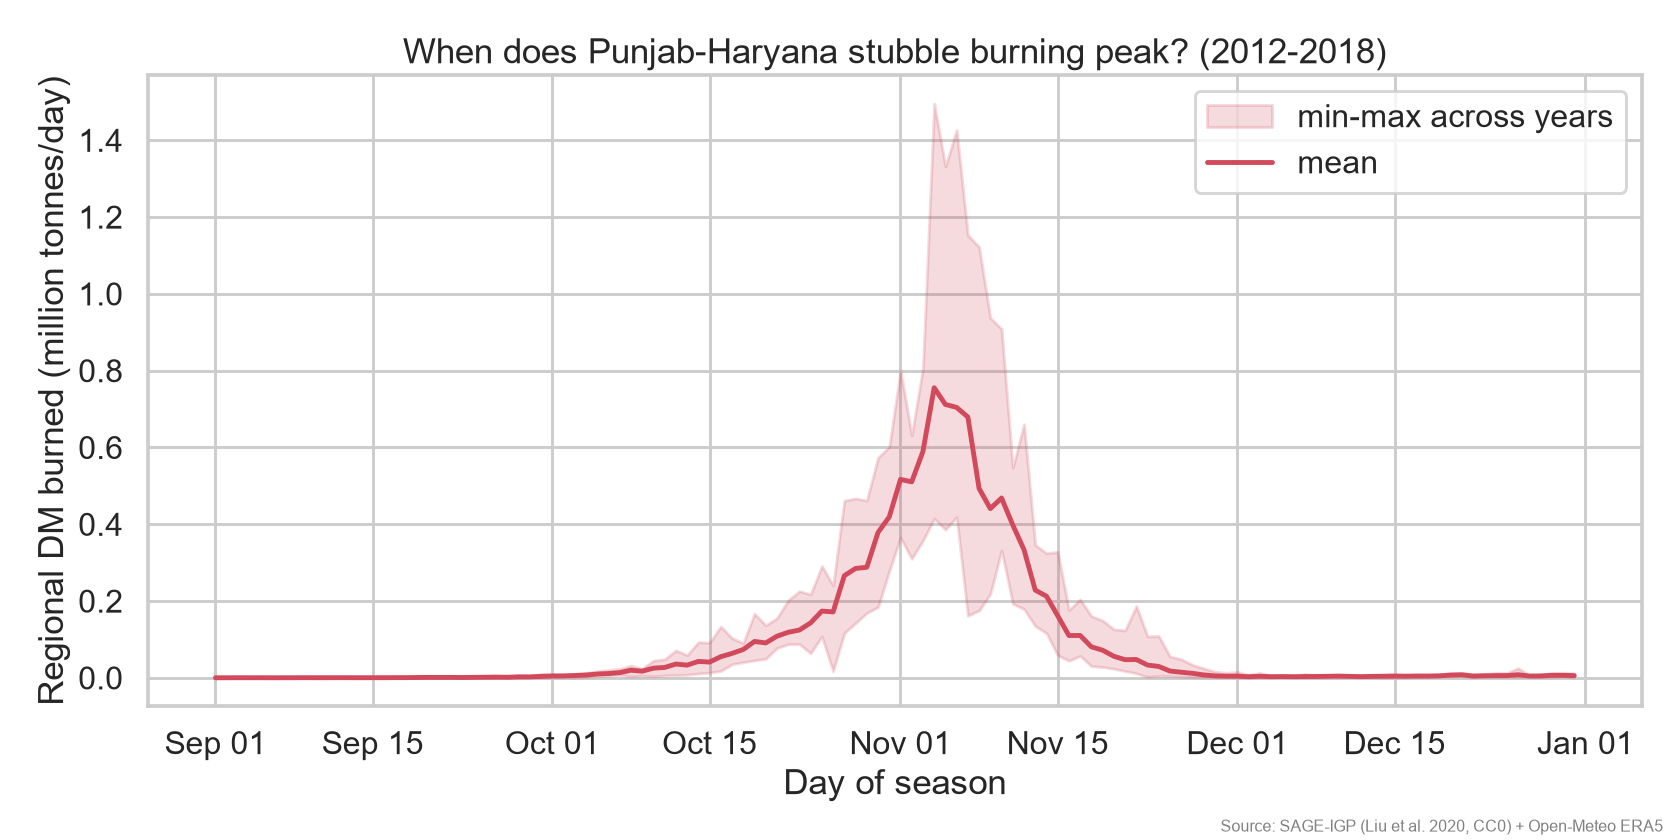

In [4]:
for _p in ['reports/figures/04_seasonal_timing.png']:
    display(Image(filename=_p))

### Fire vs weather — weak at the seasonal scale
This is the clue that weather *gates* burning but doesn't decide *where* it concentrates (confirmed by the prediction ablation in notebook 03).

In [5]:
corrs = E.fig_fire_weather(fire, weather)
print('District-season correlations (DM vs driver):')
for k,v in corrs.items(): print(f'  {k:12s} r = {v:+.2f}')

District-season correlations (DM vs driver):
  rain_days    r = +0.05
  precip_sum   r = +0.09
  et0_sum      r = -0.03


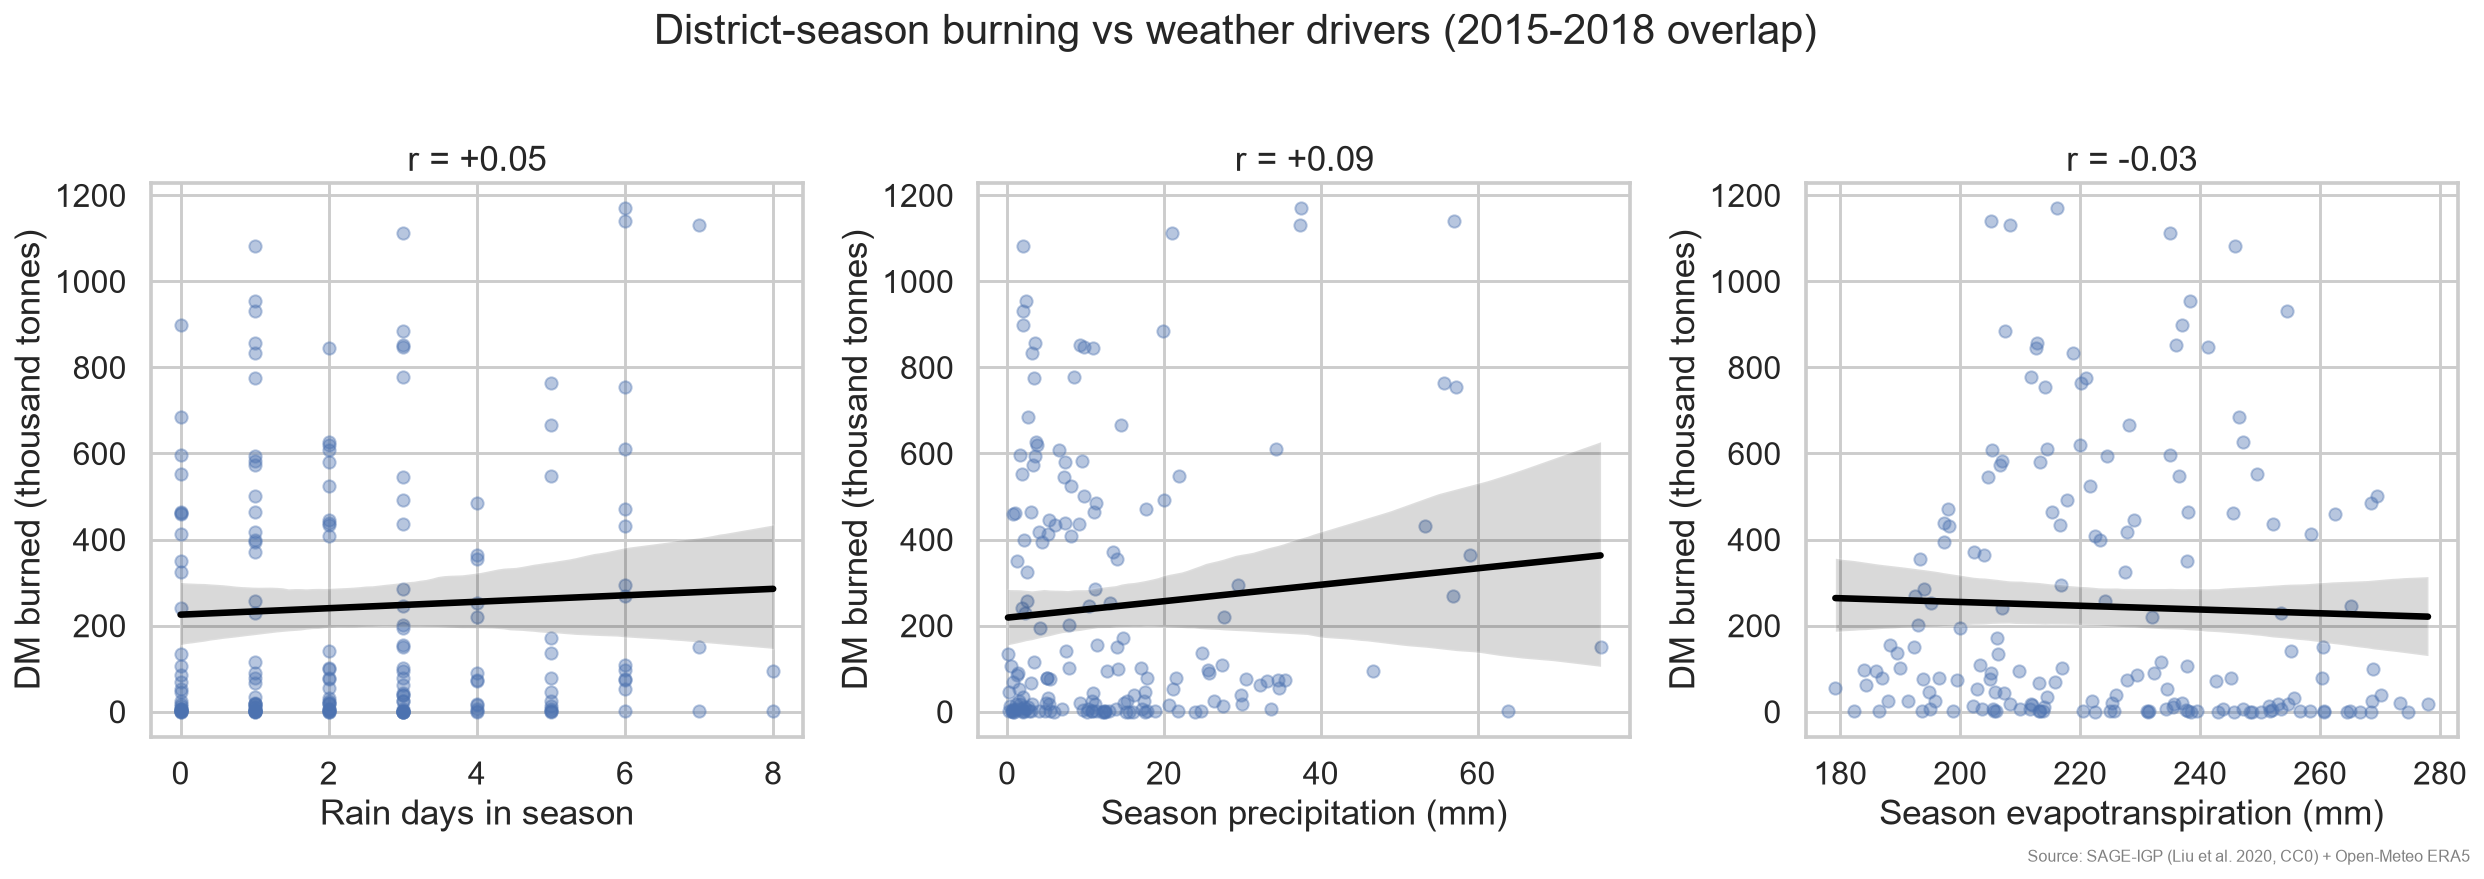

In [6]:
for _p in ['reports/figures/03_fire_vs_weather.png']:
    display(Image(filename=_p))

An interactive district choropleth is written to [`reports/hotspot_map.html`](../reports/hotspot_map.html).